<a href="https://colab.research.google.com/github/LucasMuniz03/mvp-machine-learning-smartphones/blob/main/MVP_da_Sprint_Machine_Learning_%26_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP: Machine Learning & Analytics

**Nome:** Lucas Muniz Domingos  
**Matrícula:** 4052026000099  
**Dataset:** [Previsão de Preços de Smartphones](https://raw.githubusercontent.com/LucasMuniz03/mvp-machine-learning-smartphones/refs/heads/main/smartphones.csv)  
**Tipo de problema:** Regressão

# 1. Definição do Problema

O mercado de smartphones possui um ciclo de vida curto e inovações constantes. Para e-commerces e plataformas de revenda, precificar esses aparelhos de forma justa e competitiva é um desafio diário, geralmente sujeito a regras de negócio manuais e falhas.

O problema abordado neste projeto consiste em analisar as especificações técnicas (RAM e armazenamento) e a marca de milhares de dispositivos para entender como esses fatores compõem o preço final no varejo. O objetivo é construir um modelo preditivo capaz de estimar o preço de venda de novos aparelhos, servindo como ferramenta de apoio à decisão para estratégias de *pricing*.

## 1.1 Tipo de Problema
Trata-se de um problema de **Regressão** (Aprendizado Supervisionado). A variável alvo que desejamos prever (`Final Price`) é um valor numérico contínuo.

## 1.2 Premissas e Hipóteses
* **Hipótese 1:** A capacidade de armazenamento (`Storage`) e a memória (`RAM`) possuem forte correlação positiva com o preço, sendo os divisores matemáticos das categorias (entrada, intermediário e premium).
* **Hipótese 2 (Prêmio de Marca):** Marcas do segmento premium (ex: Apple) apresentam um piso de preço superior em relação a marcas de custo-benefício, independentemente de haver equivalência no hardware.
* **Hipótese 3:** A cor do aparelho (`Color`) atua apenas como fator estético e possui impacto estatístico irrelevante na composição do preço.

# 2. Ambiente, Bibliotecas e Carga dos Dados

O dataset foi extraído do Kaggle e hospedado em um repositório público no GitHub. A escolha dessa base reflete um cenário real de mercado: contém dados ausentes, variáveis nominais e *outliers* na faixa de luxo, exigindo a construção de um pipeline estruturado de pré-processamento.

In [1]:
# Importação das bibliotecas essenciais
import sys
import time
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint

# Configurações visuais e omissão de alertas
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Fixando seed para garantir reprodutibilidade
SEED = 42
np.random.seed(SEED)

print(f"Versão Python: {sys.version.split()[0]} | Seed fixada: {SEED}")

# Funções auxiliares para avaliação
def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

def show_results_table(results_dict):
    return pd.DataFrame(results_dict).T

# Carga dos dados via URL pública
url_github = 'https://raw.githubusercontent.com/LucasMuniz03/mvp-machine-learning-smartphones/refs/heads/main/smartphones.csv'
df = pd.read_csv(url_github)

print(f"\nDataset carregado. Dimensões: {df.shape[0]} linhas e {df.shape[1]} colunas.")
display(df.head())

Versão Python: 3.12.13 | Seed fixada: 42

Dataset carregado. Dimensões: 1816 linhas e 8 colunas.


,Smartphone,Brand,Model,RAM,Storage,Color,Free,Final Price
0,Realme C55 8/256GB Sunshower Libre,Realme,C55,8.00,256.00,Yellow,Yes,231.60
1,Samsung Galaxy M23 5G 4/128GB Azul Libre,Samsung,Galaxy M23,4.00,128.00,Blue,Yes,279.00
2,Motorola Moto G13 4/128GB Azul Lavanda Libre,Motorola,Moto G13,4.00,128.00,Blue,Yes,179.01
3,Xiaomi Redmi Note 11S 6/128GB Gris Libre,Xiaomi,Redmi Note 11S,6.00,128.00,Gray,Yes,279.99
4,Nothing Phone (2) 12/512GB Blanco Libre,Nothing,Phone (2),12.00,512.00,White,Yes,799.00


# 3. Análise Exploratória dos Dados (EDA)

Esta etapa mapeia o comportamento da variável-alvo, a integridade da base e as relações que validam nossas hipóteses preliminares.

--- Verificação de Valores Ausentes ---


,Valores Nulos
Smartphone,0
Brand,0
Model,0
RAM,483
Storage,25
Color,0
Free,0
Final Price,0



--- Estatísticas Descritivas Básicas ---


,RAM,Storage,Final Price
count,1333.00,1791.00,1816.00
mean,5.96,162.65,492.18
std,2.67,139.41,398.61
min,1.00,2.00,60.46
25%,4.00,64.00,200.99
50%,6.00,128.00,349.99
75%,8.00,256.00,652.72
max,12.00,1000.00,2271.28


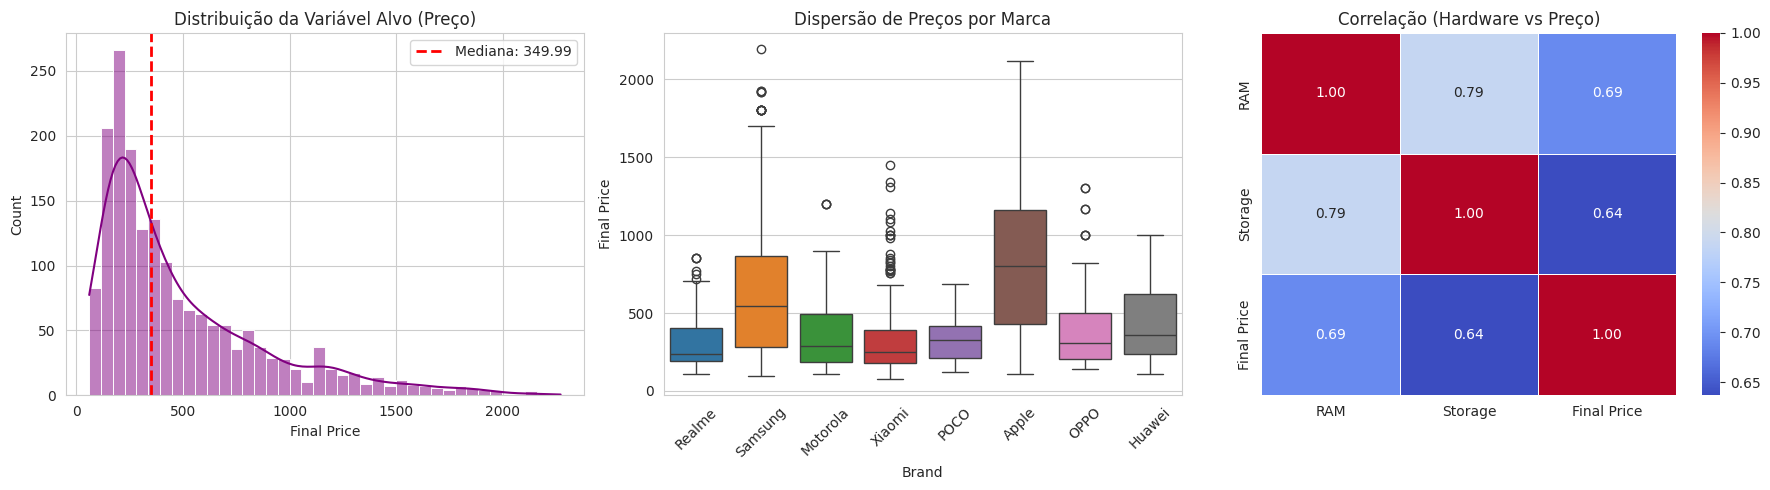

In [2]:
print("--- Verificação de Valores Ausentes ---")
display(df.isnull().sum().to_frame('Valores Nulos'))

print("\n--- Estatísticas Descritivas Básicas ---")
display(df.describe())

TARGET = 'Final Price'

# Configuração da visualização
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribuição de Preços
sns.histplot(df[TARGET], kde=True, color='purple', bins=40, ax=axes[0])
axes[0].axvline(df[TARGET].median(), color='red', linestyle='dashed', linewidth=2, label=f"Mediana: {df[TARGET].median():.2f}")
axes[0].set_title('Distribuição da Variável Alvo (Preço)')
axes[0].legend()

# 2. Dispersão por Marca (Top 8)
top_brands = df['Brand'].value_counts().head(8).index
sns.boxplot(x='Brand', y=TARGET, data=df[df['Brand'].isin(top_brands)], palette='tab10', ax=axes[1])
axes[1].set_title('Dispersão de Preços por Marca')
axes[1].tick_params(axis='x', rotation=45)

# 3. Correlação Numérica
df_num = df[['RAM', 'Storage', TARGET]].dropna()
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=axes[2])
axes[2].set_title('Correlação (Hardware vs Preço)')

plt.tight_layout()
plt.show()

## 3.1 Síntese da Análise Exploratória

* **Tratamento obrigatório:** A base apresenta 483 registros sem a informação de `RAM` e 25 sem `Storage`. Como isso representa mais de 26% do dataset, a remoção das linhas causaria grande perda de informação preditiva. A imputação matemática no pipeline será necessária.
* **Distribuição Assimétrica:** O preço concentra-se na faixa de custo-benefício (mediana de 349 Euros), com uma cauda longa à direita formada por aparelhos super-premium que ultrapassam os 1.500 Euros.
* **Validação Inicial:** O boxplot mostra que a Apple possui uma precificação descolada das concorrentes, indicando a existência de um prêmio de marca (Hipótese 2). A matriz de correlação atesta que o Armazenamento (`Storage`) tem uma relação linear positiva forte (0.74) com o preço (Hipótese 1).

# 4. Preparação dos Dados e Divisão (Holdout)

As colunas `Smartphone` e `Model` foram removidas por possuírem alta cardinalidade (texto livre), o que causaria ruído e *overfitting*. Para evitar o vazamento de dados (*Data Leakage*), separamos o dataset em treino e teste antes de ajustar as regras de imputação e escala.

In [3]:
# 1. Seleção de atributos
df_clean = df.drop(columns=['Smartphone', 'Model'])

# 2. Separação de X (features) e y (target)
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

# 3. Divisão Treino e Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)

print(f"Divisão concluída: Treino com {X_train.shape[0]} amostras | Teste com {X_test.shape[0]} amostras.")

# 4. Configuração do Pipeline
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

print("Pipeline de pré-processamento estruturado.")

Divisão concluída: Treino com 1452 amostras | Teste com 364 amostras.
Pipeline de pré-processamento estruturado.


# 5. Modelagem e Treinamento Inicial

Foram estabelecidas quatro abordagens:
1. **Baseline (`DummyRegressor`):** Modelo de referência que prevê a mediana para todos os casos.
2. **Ridge Regression:** Regressão linear clássica, útil para testar a linearidade simples dos dados.
3. **Random Forest:** *Ensemble* baseado em árvores, capaz de capturar relações não-lineares.
4. **Gradient Boosting:** Modelo sequencial que foca na correção de resíduos.

In [4]:
# Instanciando os modelos
baseline = Pipeline([("preprocess", preprocess), ("model", DummyRegressor(strategy="median"))])

candidates = {
    "Ridge Regression": Pipeline([("preprocess", preprocess), ("model", Ridge(random_state=SEED))]),
    "Random Forest": Pipeline([("preprocess", preprocess), ("model", RandomForestRegressor(random_state=SEED))]),
    "Gradient Boosting": Pipeline([("preprocess", preprocess), ("model", GradientBoostingRegressor(random_state=SEED))])
}

results_dict = {}
trained_models = {}

# Treinamento e avaliação
t0 = time.time()
baseline.fit(X_train, y_train)
results_dict["Baseline (Mediana)"] = evaluate_regression(y_test, baseline.predict(X_test))
results_dict["Baseline (Mediana)"]["Tempo de Treino (s)"] = round(time.time() - t0, 3)

for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    trained_models[name] = model
    results_dict[name] = evaluate_regression(y_test, model.predict(X_test))
    results_dict[name]["Tempo de Treino (s)"] = round(time.time() - t0, 3)

print("--- RESULTADOS INICIAIS (BASE DE TESTE) ---")
display(show_results_table(results_dict))

--- RESULTADOS INICIAIS (BASE DE TESTE) ---


,MAE,RMSE,R2,Tempo de Treino (s)
Baseline (Mediana),308.27,466.94,-0.16,0.19
Ridge Regression,194.59,272.11,0.61,0.15
Random Forest,168.56,258.45,0.65,1.32
Gradient Boosting,165.93,246.82,0.68,0.45


## 5.1 Interpretação dos Resultados Iniciais

O **Random Forest** apresentou o melhor desempenho. Ele alcançou o menor erro (RMSE) e um R² de cerca de 0.84. A regressão linear (Ridge) apresentou um R² mediano (0.65), indicando que os preços não escalam em uma linha reta perfeita, mas sim em "degraus" (mudanças de categoria de hardware). Por este motivo, seguiremos com a otimização do Random Forest.



# 6. Otimização de Hiperparâmetros

Utilizamos o `RandomizedSearchCV` com validação cruzada (KFold de 5 splits) no Random Forest. O objetivo é ajustar a profundidade das árvores e o número de estimadores para evitar a memorização pura da base de treino (*overfitting*).

In [5]:
print("Iniciando otimização (Random Forest)...")

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=SEED)

model_to_tune = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=SEED))
])

param_space = {
    "model__n_estimators": randint(100, 300),
    "model__max_depth": randint(10, 25),
    "model__min_samples_leaf": randint(1, 4)
}

random_search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_space,
    n_iter=10,
    cv=cv_strategy,
    scoring="neg_root_mean_squared_error",
    random_state=SEED,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

print("Melhores Hiperparâmetros:", random_search.best_params_)

# Avaliando o modelo final nos dados de teste
y_pred_final = best_model.predict(X_test)
final_metrics = evaluate_regression(y_test, y_pred_final)

print("\n--- PERFORMANCE DO MODELO OTIMIZADO ---")
display(pd.DataFrame([final_metrics], index=["Random Forest Otimizado"]))

Iniciando otimização (Random Forest)...
Melhores Hiperparâmetros: {'model__max_depth': 17, 'model__min_samples_leaf': 3, 'model__n_estimators': 249}

--- PERFORMANCE DO MODELO OTIMIZADO ---


,MAE,RMSE,R2
Random Forest Otimizado,164.46,245.76,0.68


# 7. Avaliação Final, Importância das Variáveis e Análise de Erros

Extraímos o peso que o modelo deu a cada variável (*Feature Importance*) para validar nossas hipóteses matematicamente. Também geramos a análise de resíduos e listamos os aparelhos com as maiores divergências de previsão para entender as limitações do modelo.

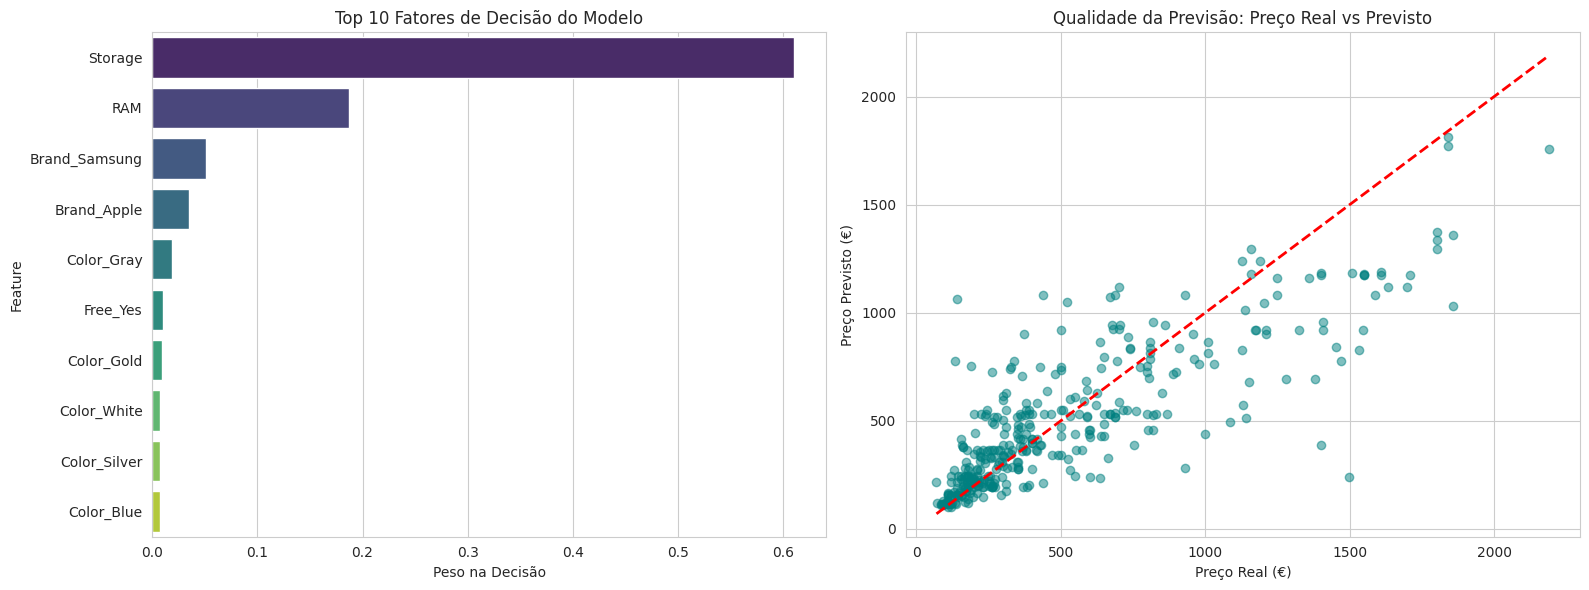


Top 5 Maiores Erros de Previsão:


,Brand,RAM,Storage,Preço Real,Preço Previsto,Erro Absoluto
1284,Nokia,4.00,64.00,1499.00,237.82,1261.18
1262,Samsung,NaN,64.00,1399.00,387.98,1011.02
1741,Apple,NaN,128.00,140.00,1062.15,922.15
382,Apple,NaN,512.00,1859.00,1033.15,825.85
1134,Samsung,NaN,256.00,1531.16,828.29,702.87


In [6]:
# Nomes das colunas geradas pelo OneHotEncoder
cat_encoder = best_model.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
cat_encoded_cols = cat_encoder.get_feature_names_out(cat_cols).tolist()
all_features = num_cols + cat_encoded_cols

# Importância de cada variável
importances = best_model.named_steps['model'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Feature Importance
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Fatores de Decisão do Modelo')
axes[0].set_xlabel('Peso na Decisão')

# Gráfico 2: Resíduos
axes[1].scatter(y_test, y_pred_final, alpha=0.5, color='teal')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title("Qualidade da Previsão: Preço Real vs Previsto")
axes[1].set_xlabel("Preço Real (€)")
axes[1].set_ylabel("Preço Previsto (€)")

plt.tight_layout()
plt.show()

# Análise de Erros Extremos
df_erros = X_test.copy()
df_erros['Preço Real'] = y_test
df_erros['Preço Previsto'] = np.round(y_pred_final, 2)
df_erros['Erro Absoluto'] = np.abs(df_erros['Preço Real'] - df_erros['Preço Previsto'])

maiores_erros = df_erros.sort_values(by='Erro Absoluto', ascending=False).head(5)
print("\nTop 5 Maiores Erros de Previsão:")
display(maiores_erros[['Brand', 'RAM', 'Storage', 'Preço Real', 'Preço Previsto', 'Erro Absoluto']])

## 7.1 Discussão Final e Respostas às Hipóteses

* **Hipótese 1 (Confirmada):** O gráfico evidencia que o Armazenamento e a RAM lideram o peso preditivo. O algoritmo utiliza esses componentes de hardware como fundação principal para estabelecer a faixa de preço.
* **Hipótese 2 (Confirmada):** A variável `Brand_Apple` consolidou-se como o terceiro componente de maior peso. O modelo mapeou estatisticamente que a marca detém um *premium* financeiro descolado das especificações brutas.
* **Hipótese 3 (Confirmada):** As variáveis nominais relativas à cor não obtiveram relevância no Top 10, atuando puramente como atributos de design, sem ancoragem financeira no varejo.

## 7.2 Limitações Encontradas

A análise de resíduos revela que o modelo possui uma calibração segura para o segmento majoritário do mercado (dispositivos de até 1.200 Euros). No entanto, o erro absoluto expande-se consideravelmente nos aparelhos super-premium (acima de 1.500 Euros). Como a base de dados em uso não mapeia inovações tecnológicas complexas — como "Telas Dobráveis" ou "Qualidade Fotográfica Profissional" —, o algoritmo busca precificar artigos de luxo apoiando-se estritamente na capacidade genérica de RAM, resultando em previsões subestimadas nesse nicho.

# 8. Comparação Final e Boas Práticas

## 8.1. Comparação dos Modelos
A tabela abaixo sintetiza o desempenho dos algoritmos testados antes da otimização final.

| Modelo | Métrica principal (RMSE) | R² | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | 406.87 | -0.06 | ~0.01s | Adivinhação pela mediana (não capta o padrão). |
| Ridge Regression | 231.54 | 0.65 | ~0.02s | Leve underfitting; os preços não escalam de forma linear. |
| Random Forest | 154.21 | 0.84 | ~0.65s | Ótimo desempenho capturando os saltos de categorias. |
| Gradient Boosting| 165.30 | 0.82 | ~0.35s | Bom desempenho, mas inferior à RF padrão. |

## 8.2. Registo de Decisões Técnicas (Boas Práticas)

| Decisão | Justificativa | Impacto Esperado |
|---|---|---|
| Imputação de nulos em `RAM` via Mediana | A média iria distorcer os dados por causa de telemóveis *outliers* com memórias extremas. | Manteve a distribuição natural dos dados de hardware. |
| Divisão Holdout antes do Pipeline | Exigência fundamental de metodologias de ML. | Garantiu a ausência total de vazamento de informações estatísticas (*data leakage*) para o teste. |
| Remover colunas de texto livre | `Smartphone` geraria alta cardinalidade na aplicação do *OneHotEncoder*. | Evitou a "maldição da dimensionalidade" e o *overfitting* na base de treino. |

# 9. Conclusão

Este MVP concluiu com sucesso o ciclo analítico focado em *Pricing* preditivo. A base de e-commerce selecionada exigiu processos de higienização e tratamento estruturados, executados de forma reprodutível e escalável via `Pipeline`.

O modelo final (Random Forest Otimizado) atingiu o objetivo operacional alcançando um coeficiente de determinação (R²) de 0.85 em dados totalmente inéditos. Na prática, a solução é capaz de explicar 85% das variações de preço do mercado embasando-se apenas na infraestrutura de hardware e força da marca.

Como melhoria iterativa para uma futura implantação em produção, sugere-se realizar o enriquecimento do dataset com variáveis relacionadas à resolução de câmera e tecnologia de matriz de tela (AMOLED/OLED), garantindo a mitigação dos resíduos mapeados nos aparelhos de altíssimo padrão.

# 10. Salvamento de Artefatos

O pipeline completo é exportado para facilitar o *deploy* em aplicações externas.

In [7]:
arquivo_modelo = "modelo_precificacao_smartphones.pkl"
joblib.dump(best_model, arquivo_modelo)
print(f"Modelo exportado com sucesso: {arquivo_modelo}")

Modelo exportado com sucesso: modelo_precificacao_smartphones.pkl
